In [22]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image


In [23]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 1

def load_image(image_path):
    img = Image.open(image_path).resize((IMG_WIDTH, IMG_HEIGHT))
    img = np.array(img).astype(np.float32)
    img = (img / 127.5) - 1.0  # Normalize to [-1, 1]
    return img

def load_dataset(folder_path):
    images = glob.glob(folder_path + '/*.jpg')  # or .png
    dataset = [load_image(img) for img in images]
    return np.array(dataset)

normal_imgs = load_dataset('C:\\Users\\Nimiti\\Downloads\\Brain_tumor_images\\Normal')
tumor_imgs = load_dataset('C:\\Users\\Nimiti\\Downloads\\Brain_tumor_images\\Tumor')

# Create TensorFlow datasets
normal_dataset = tf.data.Dataset.from_tensor_slices(normal_imgs).shuffle(100).batch(BATCH_SIZE)
tumor_dataset = tf.data.Dataset.from_tensor_slices(tumor_imgs).shuffle(100).batch(BATCH_SIZE)


In [24]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result


In [25]:
def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2DTranspose(filters, size, strides=2,
                                      padding='same',
                                      kernel_initializer=initializer,
                                      use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result


In [26]:
def Generator():
    inputs = layers.Input(shape=[IMG_HEIGHT, IMG_WIDTH, 3])
    x = inputs

    down_stack = [
        downsample(64, 4, apply_batchnorm=False),
        downsample(128, 4),
        downsample(256, 4)
    ]

    up_stack = [
        upsample(128, 4),
        upsample(64, 4)
    ]

    for down in down_stack:
        x = down(x)

    for up in up_stack:
        x = up(x)

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4,
                                  strides=2,
                                  padding='same',
                                  kernel_initializer=initializer,
                                  activation='tanh')
    x = last(x)
    return tf.keras.Model(inputs=inputs, outputs=x)


In [27]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    inp = layers.Input(shape=[IMG_HEIGHT, IMG_WIDTH, 3], name='input_image')

    x = inp
    x = downsample(64, 4, False)(x)
    x = downsample(128, 4)(x)
    x = downsample(256, 4)(x)

    zero_pad1 = layers.ZeroPadding2D()(x)
    conv = layers.Conv2D(512, 4, strides=1,
                         kernel_initializer=initializer,
                         use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)
    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)

    last = layers.Conv2D(1, 4, strides=1,
                         kernel_initializer=initializer)(zero_pad2)

    return tf.keras.Model(inputs=inp, outputs=last)


In [28]:
generator_g = Generator()  # Normal → Tumor
generator_f = Generator()  # Tumor → Normal

discriminator_x = Discriminator()  # Discriminator for Tumor
discriminator_y = Discriminator()  # Discriminator for Normal


In [29]:
loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, generated):
    real_loss = loss_obj(tf.ones_like(real), real)
    generated_loss = loss_obj(tf.zeros_like(generated), generated)
    return (real_loss + generated_loss) * 0.5

def generator_loss(generated):
    return loss_obj(tf.ones_like(generated), generated)

LAMBDA = 10

def cycle_consistency_loss(real_image, cycled_image):
    return tf.reduce_mean(tf.abs(real_image - cycled_image)) * LAMBDA

def identity_loss(real_image, same_image):
    return tf.reduce_mean(tf.abs(real_image - same_image)) * LAMBDA * 0.5


In [30]:
generator_g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

discriminator_x_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


In [31]:
@tf.function
def train_step(real_x, real_y):
    with tf.GradientTape(persistent=True) as tape:
        fake_y = generator_g(real_x, training=True)
        cycled_x = generator_f(fake_y, training=True)

        fake_x = generator_f(real_y, training=True)
        cycled_y = generator_g(fake_x, training=True)

        same_x = generator_f(real_x, training=True)
        same_y = generator_g(real_y, training=True)

        disc_real_x = discriminator_x(real_x, training=True)
        disc_real_y = discriminator_y(real_y, training=True)

        disc_fake_x = discriminator_x(fake_x, training=True)
        disc_fake_y = discriminator_y(fake_y, training=True)

        gen_g_loss = generator_loss(disc_fake_y)
        gen_f_loss = generator_loss(disc_fake_x)

        total_cycle_loss = cycle_consistency_loss(real_x, cycled_x) + cycle_consistency_loss(real_y, cycled_y)

        total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y)
        total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x)

        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    generator_g_gradients = tape.gradient(total_gen_g_loss, generator_g.trainable_variables)
    generator_f_gradients = tape.gradient(total_gen_f_loss, generator_f.trainable_variables)

    discriminator_x_gradients = tape.gradient(disc_x_loss, discriminator_x.trainable_variables)
    discriminator_y_gradients = tape.gradient(disc_y_loss, discriminator_y.trainable_variables)

    generator_g_optimizer.apply_gradients(zip(generator_g_gradients, generator_g.trainable_variables))
    generator_f_optimizer.apply_gradients(zip(generator_f_gradients, generator_f.trainable_variables))

    discriminator_x_optimizer.apply_gradients(zip(discriminator_x_gradients, discriminator_x.trainable_variables))
    discriminator_y_optimizer.apply_gradients(zip(discriminator_y_gradients, discriminator_y.trainable_variables))


In [13]:
EPOCHS = 100

for epoch in range(EPOCHS):
    print("Epoch", epoch + 1)
    for image_x, image_y in tf.data.Dataset.zip((normal_dataset, tumor_dataset)):
        train_step(image_x, image_y)


Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19
Epoch 20
Epoch 21
Epoch 22
Epoch 23
Epoch 24
Epoch 25
Epoch 26
Epoch 27
Epoch 28
Epoch 29
Epoch 30
Epoch 31
Epoch 32
Epoch 33
Epoch 34
Epoch 35
Epoch 36
Epoch 37
Epoch 38
Epoch 39
Epoch 40
Epoch 41
Epoch 42
Epoch 43
Epoch 44
Epoch 45
Epoch 46
Epoch 47
Epoch 48
Epoch 49
Epoch 50
Epoch 51
Epoch 52
Epoch 53
Epoch 54
Epoch 55
Epoch 56
Epoch 57
Epoch 58
Epoch 59
Epoch 60
Epoch 61
Epoch 62
Epoch 63
Epoch 64
Epoch 65
Epoch 66
Epoch 67
Epoch 68
Epoch 69
Epoch 70
Epoch 71
Epoch 72
Epoch 73
Epoch 74
Epoch 75
Epoch 76
Epoch 77
Epoch 78
Epoch 79
Epoch 80
Epoch 81
Epoch 82
Epoch 83
Epoch 84
Epoch 85
Epoch 86
Epoch 87
Epoch 88
Epoch 89
Epoch 90
Epoch 91
Epoch 92
Epoch 93
Epoch 94
Epoch 95
Epoch 96
Epoch 97
Epoch 98
Epoch 99
Epoch 100


In [32]:
generator_g.save("C:\\Brain Stroke image dataset\\Brain_Data_Organised\\brain_tumor_model.h5")  # optional: if saved as .h5
# or use checkpoint restore if using tf.train.Checkpoint


In [35]:
generator_g = tf.keras.models.load_model('C:\Brain Stroke image dataset\\Brain_Data_Organised\\brain_tumor_model.h5')  # optional: if saved as .h5
# or use checkpoint restore if using tf.train.Checkpoint


<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\Nimiti\AppData\Local\Temp\ipykernel_20664\4208823022.py:1: SyntaxWarning: invalid escape sequence '\B'
  generator_g = tf.keras.models.load_model('C:\Brain Stroke image dataset\\Brain_Data_Organised\\brain_tumor_model.h5')  # optional: if saved as .h5


In [55]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

IMG_HEIGHT = 256
IMG_WIDTH = 256

# Load & preprocess image
def load_image_test(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)  # Use decode_png for PNG
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = (tf.cast(image, tf.float32) / 127.5) - 1  # Normalize to [-1, 1]
    return image

# Generate and show image
def generate_images(model, test_input):
    print("✅ Inference starting...")
    prediction = model(test_input, training=False)
    print("✅ Prediction done, shape:", prediction.shape)

    prediction = prediction[0]
    input_img = test_input[0]

    plt.figure(figsize=(12, 6))
    display_list = [input_img, prediction]
    titles = ['Input Image', 'Generated Image']

    for i in range(2):
        plt.subplot(1, 2, i + 1)
        plt.title(titles[i])
        plt.imshow((display_list[i] + 1) / 2.0)
        plt.axis('off')

    print("✅ Saving and showing image...")
    plt.savefig("generated_output.png")  # Save fallback
    plt.show()  # This will open the image if your environment allows


In [67]:
import glob

# Use one of the safe path methods:
test_image_paths = glob.glob("C:\\Brain Stroke image dataset\\test image\\Normal (9).jpg")

if not test_image_paths:
    print("❌ No images found in the test folder. Please check the path.")
else:
    print(f"✅ Found {len(test_image_paths)} test image(s).")


✅ Found 1 test image(s).


In [68]:
IMG_HEIGHT = 256
IMG_WIDTH = 256

def load_image_test(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)  # use decode_png if needed
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = (tf.cast(image, tf.float32) / 127.5) - 1  # Normalize to [-1, 1]
    return image



In [69]:
import matplotlib.pyplot as plt

def generate_images(model, test_input):
    print("🔁 Running generator inference...")
    prediction = model(test_input, training=False)
    
    input_img = test_input[0]
    output_img = prediction[0]

    plt.figure(figsize=(12, 6))

    display_list = [input_img, output_img]
    titles = ['Input Image', 'Generated Image']

    for i in range(2):
        plt.subplot(1, 2, i + 1)
        plt.title(titles[i])
        plt.imshow((display_list[i] + 1) / 2.0)  # Rescale to [0, 1]
        plt.axis('off')

    plt.savefig("generated_output.png")  # Optional: Save the image
    plt.show()


🔁 Running generator inference...


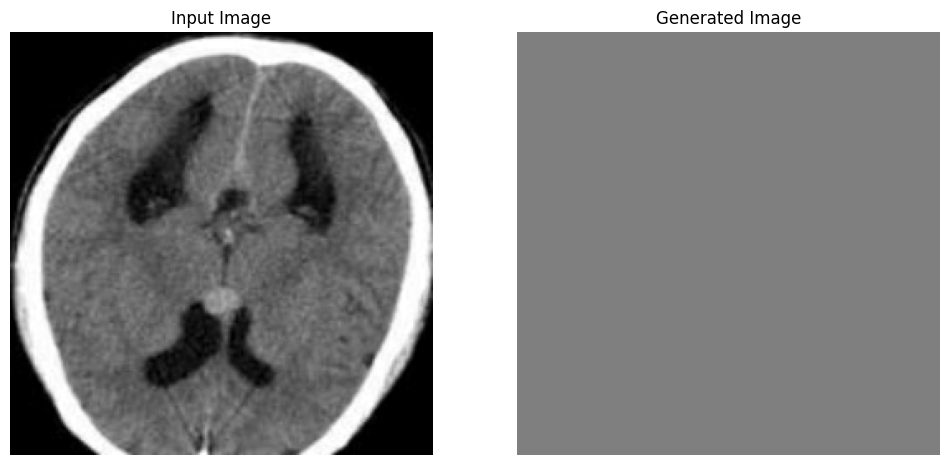

In [70]:
# Load the first test image
test_image_path = test_image_paths[0]
test_image = load_image_test(test_image_path)

# Expand dims to simulate a batch (1, 256, 256, 3)
test_image = tf.expand_dims(test_image, axis=0)

# Run generator and show output
generate_images(generator_g, test_image)
